In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from folium.plugins import HeatMap
from scipy.spatial.distance import cdist

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [21]:
DATA_DIR   = "C:\M2 SPA\Supply Chain"          # folder where you put the 9 CSVs
OUTPUT_DIR = "C:\M2 SPA\Supply Chain\outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Brazilian state abbreviations → full names (for labels)
STATE_NAMES = {
    "AC": "Acre", "AL": "Alagoas", "AP": "Amapá", "AM": "Amazonas",
    "BA": "Bahia", "CE": "Ceará", "DF": "Distrito Federal",
    "ES": "Espírito Santo", "GO": "Goiás", "MA": "Maranhão",
    "MT": "Mato Grosso", "MS": "Mato Grosso do Sul", "MG": "Minas Gerais",
    "PA": "Pará", "PB": "Paraíba", "PR": "Paraná", "PE": "Pernambuco",
    "PI": "Piauí", "RJ": "Rio de Janeiro", "RN": "Rio Grande do Norte",
    "RS": "Rio Grande do Sul", "RO": "Rondônia", "RR": "Roraima",
    "SC": "Santa Catarina", "SP": "São Paulo", "SE": "Sergipe", "TO": "Tocantins",
}



In [22]:
def load_data(data_dir: str) -> dict:
    """Load all 9 Olist CSV files into a dictionary of DataFrames."""
    files = {
        "orders"       : "olist_orders_dataset.csv",
        "items"        : "olist_order_items_dataset.csv",
        "customers"    : "olist_customers_dataset.csv",
        "sellers"      : "olist_sellers_dataset.csv",
        "products"     : "olist_products_dataset.csv",
        "payments"     : "olist_order_payments_dataset.csv",
        "reviews"      : "olist_order_reviews_dataset.csv",
        "geo"          : "olist_geolocation_dataset.csv",
        "categories"   : "product_category_name_translation.csv",
    }
    dfs = {}
    for key, fname in files.items():
        path = os.path.join(data_dir, fname)
        dfs[key] = pd.read_csv(path)
        print(f"  ✓ {key:12s}  →  {dfs[key].shape[0]:>7,} rows  ×  {dfs[key].shape[1]} cols")
    return dfs


print("\n" + "="*55)
print("  PHASE 1 — DATA ENGINEERING")
print("="*55)
print("\n[1] Loading raw CSV files …")
dfs = load_data(DATA_DIR)


  PHASE 1 — DATA ENGINEERING

[1] Loading raw CSV files …
  ✓ orders        →   99,441 rows  ×  8 cols
  ✓ items         →  112,650 rows  ×  7 cols
  ✓ customers     →   99,441 rows  ×  5 cols
  ✓ sellers       →    3,095 rows  ×  4 cols
  ✓ products      →   32,951 rows  ×  9 cols
  ✓ payments      →  103,886 rows  ×  5 cols
  ✓ reviews       →   99,224 rows  ×  7 cols
  ✓ geo           →  1,000,163 rows  ×  5 cols
  ✓ categories    →       71 rows  ×  2 cols


In [23]:
print("\n[2] Parsing dates …")
date_cols = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in date_cols:
    dfs["orders"][col] = pd.to_datetime(dfs["orders"][col], errors="coerce")

# Keep only delivered orders (status = delivered) for supply chain analysis
orders_delivered = dfs["orders"][dfs["orders"]["order_status"] == "delivered"].copy()
print(f"   Delivered orders: {len(orders_delivered):,}  "
      f"(out of {len(dfs['orders']):,} total)")



[2] Parsing dates …
   Delivered orders: 96,478  (out of 99,441 total)


In [24]:
print("\n[3] Building master analytical table …")

master = (
    orders_delivered
    .merge(dfs["items"],     on="order_id",    how="left")
    .merge(dfs["customers"], on="customer_id", how="left")
    .merge(dfs["sellers"],   on="seller_id",   how="left")
    .merge(dfs["products"],  on="product_id",  how="left")
    .merge(dfs["categories"],on="product_category_name", how="left")
)

# Rename for clarity
master.rename(columns={
    "customer_state"                 : "demand_state",
    "customer_city"                  : "demand_city",
    "customer_zip_code_prefix"       : "demand_zip",
    "seller_state"                   : "supply_state",
    "seller_city"                    : "supply_city",
    "seller_zip_code_prefix"         : "supply_zip",
    "product_category_name_english"  : "category_en",
}, inplace=True)

print(f"   Master table shape: {master.shape}")



[3] Building master analytical table …
   Master table shape: (110197, 30)


In [25]:
print("\n[4] Engineering features …")

# 4a. Delivery delay (actual vs estimated, in days)
master["delivery_delay_days"] = (
    (master["order_delivered_customer_date"] -
     master["order_estimated_delivery_date"]).dt.total_seconds() / 86400
)
master["is_late"] = (master["delivery_delay_days"] > 0).astype(int)

# 4b. Actual delivery time (purchase → delivery)
master["actual_delivery_days"] = (
    (master["order_delivered_customer_date"] -
     master["order_purchase_timestamp"]).dt.total_seconds() / 86400
)

# 4c. Order month / year
master["order_year"]  = master["order_purchase_timestamp"].dt.year
master["order_month"] = master["order_purchase_timestamp"].dt.to_period("M").astype(str)

# 4d. Product volume (cm³)
master["product_volume_cm3"] = (
    master["product_length_cm"] *
    master["product_height_cm"] *
    master["product_width_cm"]
)

# 4e. Revenue per item
master["revenue"] = master["price"] + master["freight_value"]

print(f"   New features added: delivery_delay_days, is_late, "
      f"actual_delivery_days, order_year, order_month, product_volume_cm3, revenue")



[4] Engineering features …
   New features added: delivery_delay_days, is_late, actual_delivery_days, order_year, order_month, product_volume_cm3, revenue


In [26]:
print("\n[5] Missing value audit …")
key_cols = [
    "order_id", "customer_id", "seller_id", "product_id",
    "demand_state", "supply_state", "price", "freight_value",
    "actual_delivery_days", "delivery_delay_days",
]
missing = master[key_cols].isnull().sum()
missing_pct = (missing / len(master) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0]
if missing_df.empty:
    print("   No missing values in key columns ✓")
else:
    print(missing_df.to_string())

# Drop rows missing critical supply chain fields
master.dropna(subset=["demand_state", "supply_state", "freight_value", "price"], inplace=True)
print(f"   Master table after drop: {len(master):,} rows")



[5] Missing value audit …
                      missing_count  missing_%
actual_delivery_days              8       0.01
delivery_delay_days               8       0.01
   Master table after drop: 110,197 rows


In [27]:
print("\n[6] Attaching coordinates …")

# Use median lat/lng per zip prefix to reduce noise
geo_clean = (
    dfs["geo"]
    .groupby("geolocation_zip_code_prefix")[
        ["geolocation_lat", "geolocation_lng"]
    ]
    .median()
    .reset_index()
    .rename(columns={
        "geolocation_zip_code_prefix": "zip",
        "geolocation_lat"            : "lat",
        "geolocation_lng"            : "lng",
    })
)

master = (
    master
    .merge(geo_clean.rename(columns={"zip":"demand_zip","lat":"cust_lat","lng":"cust_lng"}),
           on="demand_zip", how="left")
    .merge(geo_clean.rename(columns={"zip":"supply_zip","lat":"sell_lat","lng":"sell_lng"}),
           on="supply_zip", how="left")
)

print(f"   Coordinates attached. Rows with customer coords: "
      f"{master['cust_lat'].notna().sum():,} / {len(master):,}")



[6] Attaching coordinates …
   Coordinates attached. Rows with customer coords: 109,909 / 110,197


In [28]:
print("\n[7] Building demand & supply node tables …")

# --- DEMAND NODES (by state) ---
demand_nodes = (
    master.groupby("demand_state").agg(
        total_orders    = ("order_id",          "nunique"),
        total_items     = ("order_item_id",      "count"),
        total_revenue   = ("revenue",            "sum"),
        avg_freight     = ("freight_value",      "mean"),
        avg_delay_days  = ("delivery_delay_days","mean"),
        late_rate       = ("is_late",            "mean"),
        avg_delivery_days=("actual_delivery_days","mean"),
        centroid_lat    = ("cust_lat",           "median"),
        centroid_lng    = ("cust_lng",           "median"),
    )
    .reset_index()
    .rename(columns={"demand_state": "state"})
    .sort_values("total_orders", ascending=False)
)
demand_nodes["state_name"] = demand_nodes["state"].map(STATE_NAMES)

# --- SUPPLY NODES (by state) ---
supply_nodes = (
    master.groupby("supply_state").agg(
        n_sellers       = ("seller_id",          "nunique"),
        total_items_sold= ("order_item_id",       "count"),
        total_revenue   = ("revenue",             "sum"),
        avg_freight     = ("freight_value",       "mean"),
        centroid_lat    = ("sell_lat",            "median"),
        centroid_lng    = ("sell_lng",            "median"),
    )
    .reset_index()
    .rename(columns={"supply_state": "state"})
    .sort_values("total_items_sold", ascending=False)
)
supply_nodes["state_name"] = supply_nodes["state"].map(STATE_NAMES)

print(f"   Demand nodes: {len(demand_nodes)} states")
print(f"   Supply nodes: {len(supply_nodes)} states")

# --- ROUTE-LEVEL FLOWS ---
route_flows = (
    master.groupby(["supply_state", "demand_state"]).agg(
        flow_items    = ("order_item_id",   "count"),
        avg_freight   = ("freight_value",   "mean"),
        total_freight = ("freight_value",   "sum"),
        avg_delay     = ("delivery_delay_days","mean"),
    )
    .reset_index()
    .sort_values("flow_items", ascending=False)
)
print(f"   Route flows (supply→demand pairs): {len(route_flows)}")



[7] Building demand & supply node tables …
   Demand nodes: 27 states
   Supply nodes: 22 states
   Route flows (supply→demand pairs): 412


In [29]:
print("\n[8] Building monthly demand time series …")

monthly_demand = (
    master.groupby(["order_month", "demand_state"]).agg(
        orders    = ("order_id",    "nunique"),
        items     = ("order_item_id","count"),
        revenue   = ("revenue",     "sum"),
        freight   = ("freight_value","sum"),
    )
    .reset_index()
)
monthly_demand["order_month"] = pd.to_datetime(monthly_demand["order_month"])
monthly_demand.sort_values(["demand_state", "order_month"], inplace=True)

# National aggregate
monthly_national = (
    monthly_demand.groupby("order_month")[["orders","items","revenue"]].sum().reset_index()
)


[8] Building monthly demand time series …


In [30]:
print("\n[9] Computing approximate distance matrix between state centroids …")

def haversine_matrix(lats, lngs):
    """Return pairwise haversine distances (km) for arrays of lat/lng."""
    R = 6371
    lat_r = np.radians(lats)
    lng_r = np.radians(lngs)
    dlat = lat_r[:, None] - lat_r[None, :]
    dlng = lng_r[:, None] - lng_r[None, :]
    a = np.sin(dlat/2)**2 + np.cos(lat_r[:,None]) * np.cos(lat_r[None,:]) * np.sin(dlng/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

# Use demand_nodes centroids for the distance matrix
valid_geo = demand_nodes.dropna(subset=["centroid_lat","centroid_lng"])
dist_matrix = haversine_matrix(
    valid_geo["centroid_lat"].values,
    valid_geo["centroid_lng"].values,
)
dist_df = pd.DataFrame(
    dist_matrix,
    index=valid_geo["state"].values,
    columns=valid_geo["state"].values,
)
print(f"   Distance matrix shape: {dist_df.shape}")
print(f"   Example — SP → RJ: {dist_df.loc['SP','RJ']:.0f} km")



[9] Computing approximate distance matrix between state centroids …
   Distance matrix shape: (27, 27)
   Example — SP → RJ: 359 km


In [31]:
print("\n[10] Saving engineered datasets …")

master.to_parquet(f"{OUTPUT_DIR}/master_table.parquet", index=False)
demand_nodes.to_csv(f"{OUTPUT_DIR}/demand_nodes.csv", index=False)
supply_nodes.to_csv(f"{OUTPUT_DIR}/supply_nodes.csv", index=False)
route_flows.to_csv(f"{OUTPUT_DIR}/route_flows.csv", index=False)
monthly_demand.to_csv(f"{OUTPUT_DIR}/monthly_demand.csv", index=False)
monthly_national.to_csv(f"{OUTPUT_DIR}/monthly_national.csv", index=False)
dist_df.to_csv(f"{OUTPUT_DIR}/distance_matrix_km.csv")

print("   Saved: master_table.parquet, demand_nodes.csv, supply_nodes.csv,")
print("          route_flows.csv, monthly_demand.csv, distance_matrix_km.csv")



[10] Saving engineered datasets …
   Saved: master_table.parquet, demand_nodes.csv, supply_nodes.csv,
          route_flows.csv, monthly_demand.csv, distance_matrix_km.csv



[11] Generating EDA plots …


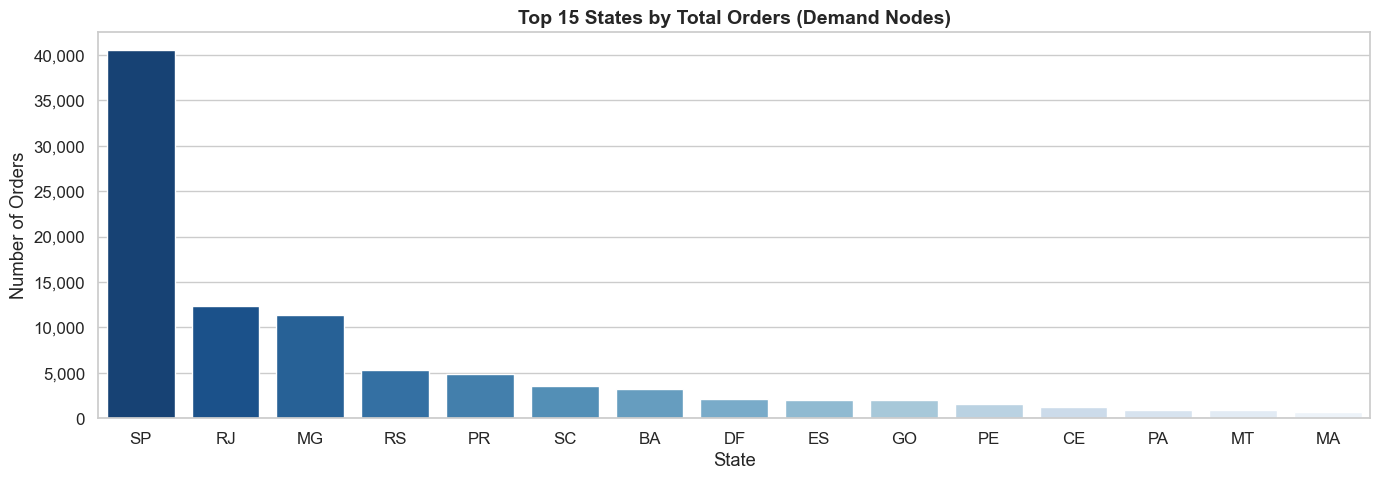

   ✓ 01_demand_by_state.png


In [32]:
print("\n[11] Generating EDA plots …")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# ── 11a. Demand by state (bar chart) ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
top = demand_nodes.sort_values("total_orders", ascending=False).head(15)
sns.barplot(data=top, x="state", y="total_orders", palette="Blues_r", ax=ax)
ax.set_title("Top 15 States by Total Orders (Demand Nodes)", fontsize=14, fontweight="bold")
ax.set_xlabel("State"); ax.set_ylabel("Number of Orders")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_demand_by_state.png", dpi=150)
plt.show()
plt.close()
print("   ✓ 01_demand_by_state.png")

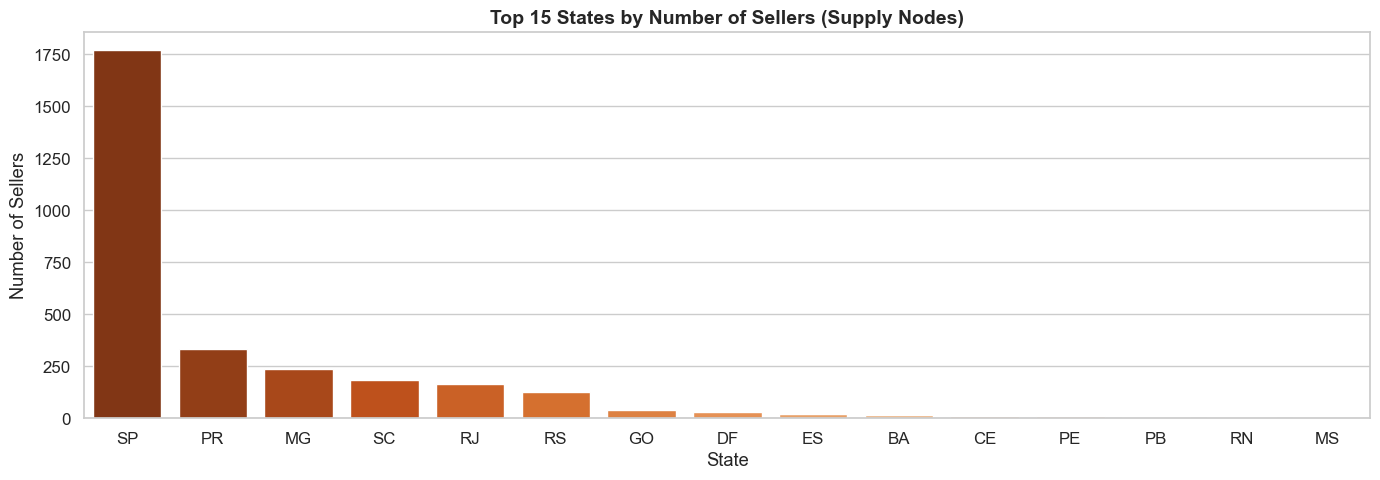

   ✓ 02_supply_by_state.png


In [33]:
fig, ax = plt.subplots(figsize=(14, 5))
top_s = supply_nodes.sort_values("n_sellers", ascending=False).head(15)
sns.barplot(data=top_s, x="state", y="n_sellers", palette="Oranges_r", ax=ax)
ax.set_title("Top 15 States by Number of Sellers (Supply Nodes)", fontsize=14, fontweight="bold")
ax.set_xlabel("State"); ax.set_ylabel("Number of Sellers")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_supply_by_state.png", dpi=150)
plt.show()
plt.close()
print("   ✓ 02_supply_by_state.png")

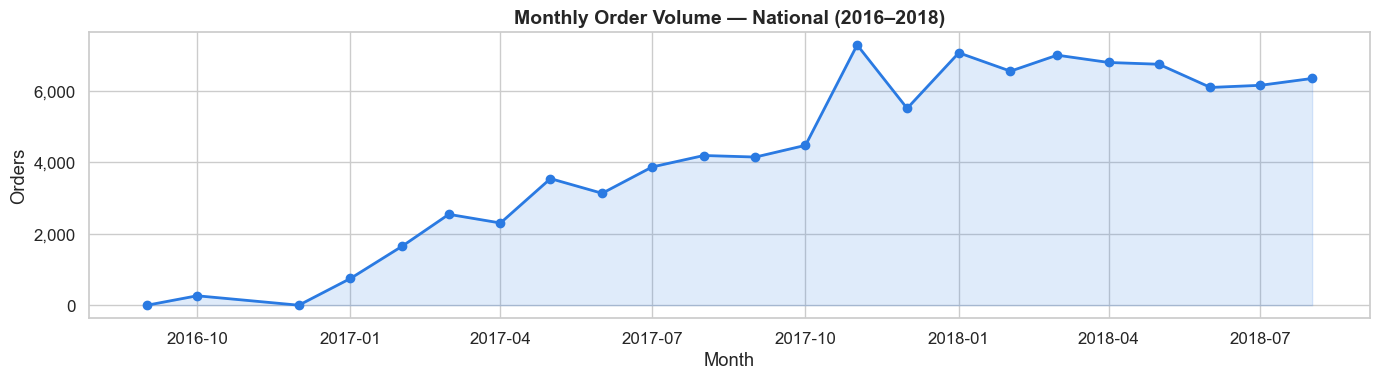

   ✓ 03_monthly_orders_national.png


In [34]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly_national["order_month"], monthly_national["orders"],
        marker="o", linewidth=2, color="#2a7ae2")
ax.fill_between(monthly_national["order_month"], monthly_national["orders"],
                alpha=0.15, color="#2a7ae2")
ax.set_title("Monthly Order Volume — National (2016–2018)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month"); ax.set_ylabel("Orders")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_monthly_orders_national.png", dpi=150)
plt.show()
plt.close()
print("   ✓ 03_monthly_orders_national.png")

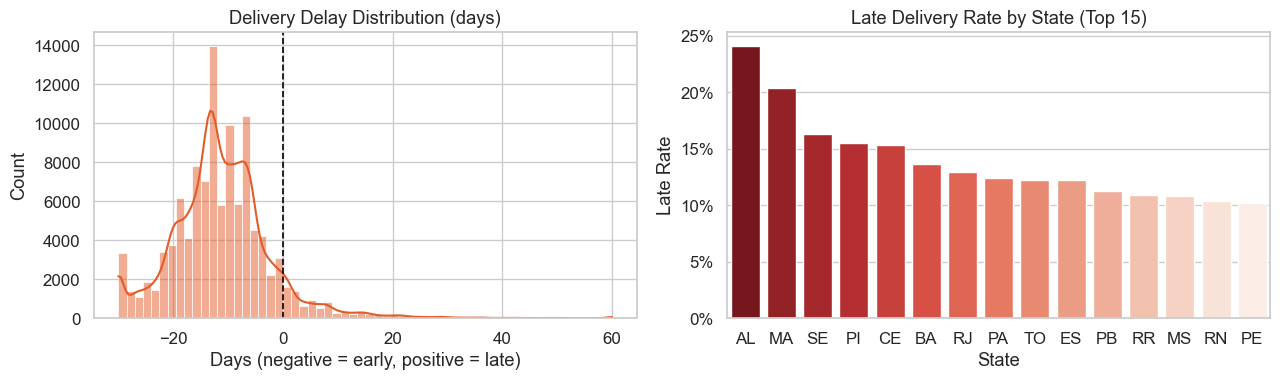

   ✓ 04_delivery_delay.png


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sample = master["delivery_delay_days"].dropna().clip(-30, 60)
sns.histplot(sample, bins=60, kde=True, ax=axes[0], color="#e25c2a")
axes[0].axvline(0, color="black", linestyle="--", linewidth=1.2)
axes[0].set_title("Delivery Delay Distribution (days)")
axes[0].set_xlabel("Days (negative = early, positive = late)")

late_by_state = (
    demand_nodes.sort_values("late_rate", ascending=False)
    .head(15)[["state","late_rate"]]
)
sns.barplot(data=late_by_state, x="state", y="late_rate",
            palette="Reds_r", ax=axes[1])
axes[1].set_title("Late Delivery Rate by State (Top 15)")
axes[1].set_xlabel("State")
axes[1].set_ylabel("Late Rate")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_delivery_delay.png", dpi=150)
plt.show()
plt.close()
print("   ✓ 04_delivery_delay.png")

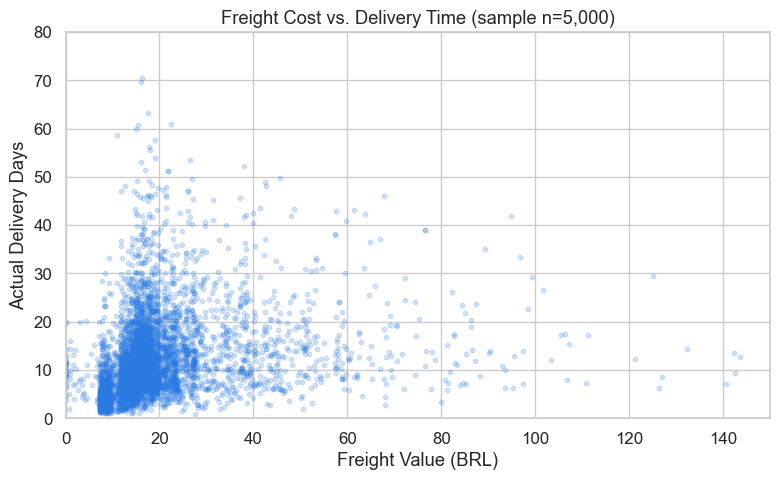

   ✓ 05_freight_vs_delivery.png


In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
sample_scatter = master.sample(min(5000, len(master)), random_state=42)
ax.scatter(sample_scatter["freight_value"], sample_scatter["actual_delivery_days"],
           alpha=0.2, s=10, color="#2a7ae2")
ax.set_xlabel("Freight Value (BRL)")
ax.set_ylabel("Actual Delivery Days")
ax.set_title("Freight Cost vs. Delivery Time (sample n=5,000)")
ax.set_xlim(0, 150); ax.set_ylim(0, 80)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_freight_vs_delivery.png", dpi=150)
plt.show()
plt.close()
print("   ✓ 05_freight_vs_delivery.png")

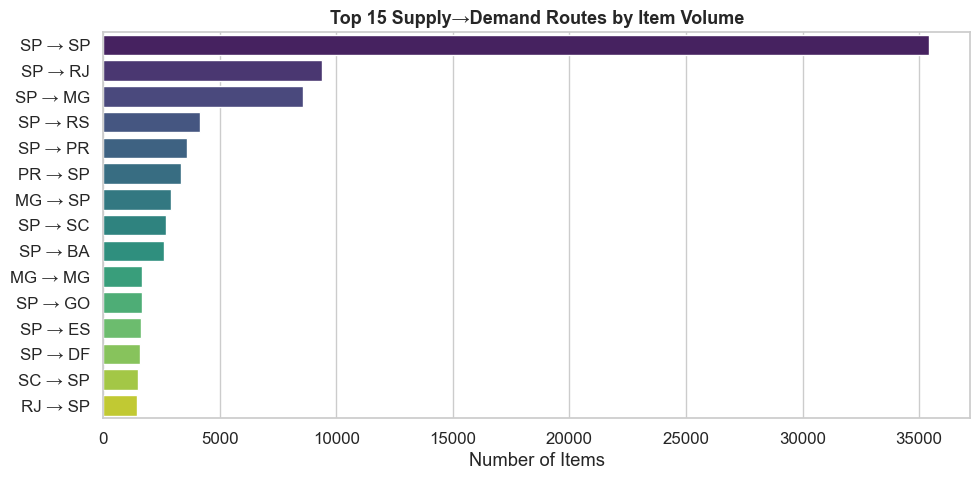

   ✓ 06_top_routes.png


In [37]:
fig, ax = plt.subplots(figsize=(10, 5))
top_routes = route_flows.head(15).copy()
top_routes["route"] = top_routes["supply_state"] + " → " + top_routes["demand_state"]
sns.barplot(data=top_routes, x="flow_items", y="route", palette="viridis", ax=ax)
ax.set_title("Top 15 Supply→Demand Routes by Item Volume", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Items"); ax.set_ylabel("")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_top_routes.png", dpi=150)
plt.show()
plt.close()
print("   ✓ 06_top_routes.png")

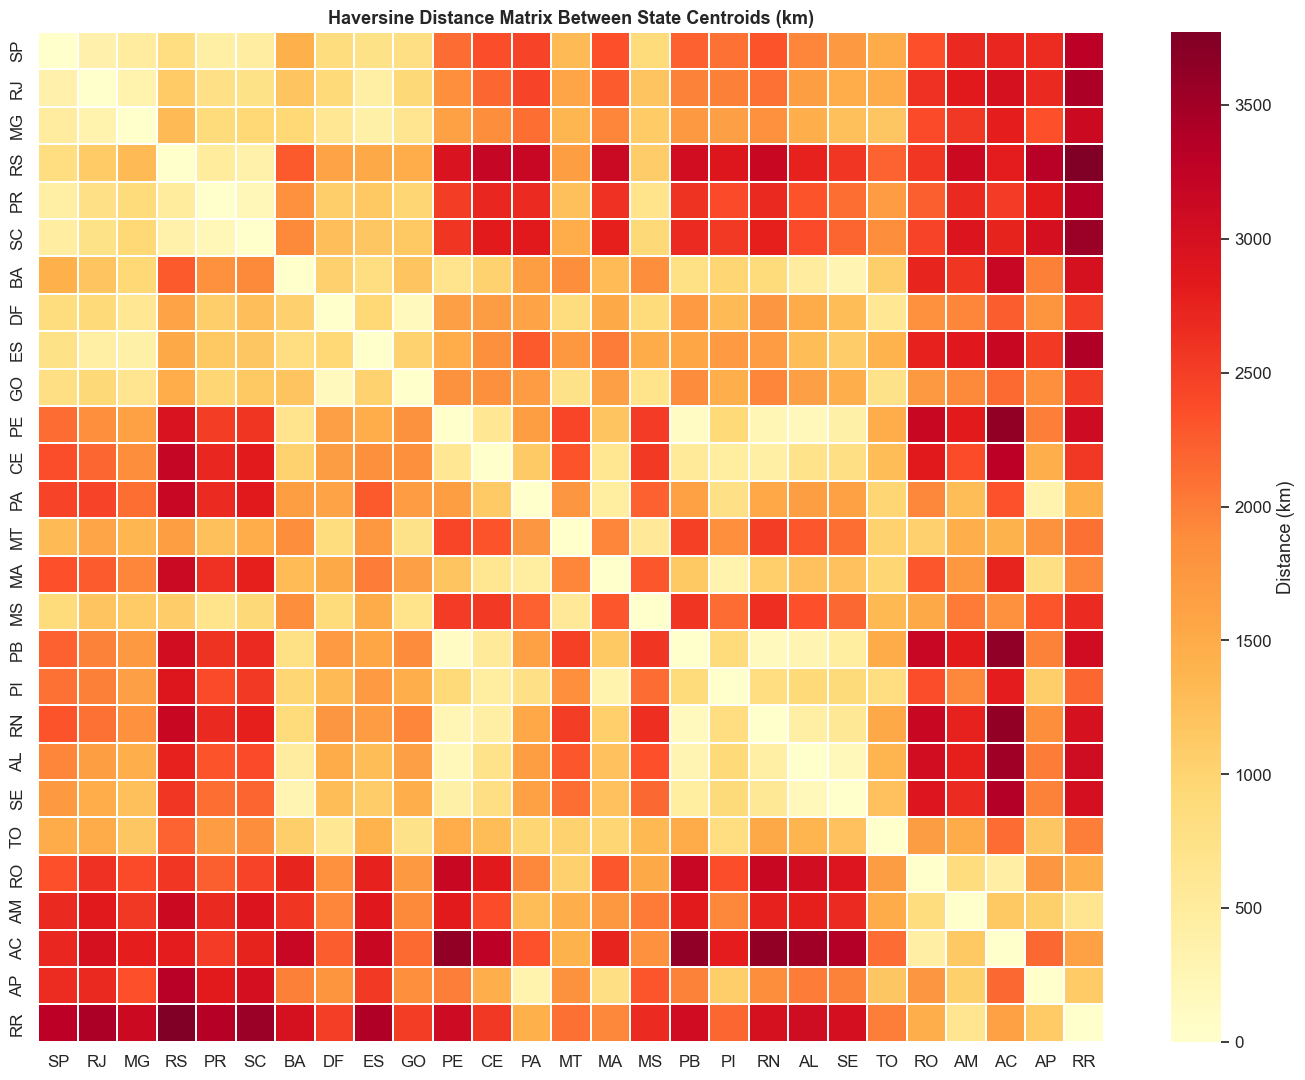

   ✓ 07_distance_matrix_heatmap.png


In [38]:
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(dist_df.astype(float), cmap="YlOrRd", linewidths=0.3,
            annot=False, ax=ax, cbar_kws={"label": "Distance (km)"})
ax.set_title("Haversine Distance Matrix Between State Centroids (km)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/07_distance_matrix_heatmap.png", dpi=150)
plt.show()
plt.close()
print("   ✓ 07_distance_matrix_heatmap.png")

In [39]:
print("\n[12] Building interactive Folium map …")

brazil_map = folium.Map(location=[-14.2, -51.9], zoom_start=4,
                        tiles="CartoDB positron")

# Demand heatmap
heat_data = demand_nodes.dropna(subset=["centroid_lat","centroid_lng"])
heat_values = list(zip(
    heat_data["centroid_lat"],
    heat_data["centroid_lng"],
    heat_data["total_orders"] / heat_data["total_orders"].max(),
))
HeatMap(heat_values, radius=35, blur=25, min_opacity=0.3).add_to(brazil_map)



[12] Building interactive Folium map …


In [40]:
for _, row in demand_nodes.dropna(subset=["centroid_lat","centroid_lng"]).iterrows():
    folium.CircleMarker(
        location=[row["centroid_lat"], row["centroid_lng"]],
        radius=5 + (row["total_orders"] / demand_nodes["total_orders"].max()) * 20,
        color="#1a6bbd", fill=True, fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>{row['state_name']} ({row['state']})</b><br>"
            f"Orders: {int(row['total_orders']):,}<br>"
            f"Avg freight: R${row['avg_freight']:.2f}<br>"
            f"Late rate: {row['late_rate']:.1%}<br>"
            f"Avg delivery: {row['avg_delivery_days']:.1f} days",
            max_width=220,
        ),
        tooltip=f"{row['state']} | {int(row['total_orders']):,} orders",
    ).add_to(brazil_map)


In [41]:
for _, row in supply_nodes.dropna(subset=["centroid_lat","centroid_lng"]).iterrows():
    folium.RegularPolygonMarker(
        location=[row["centroid_lat"], row["centroid_lng"]],
        number_of_sides=4, radius=8, rotation=45,
        color="#e07b00", fill=True, fill_color="#f5a623", fill_opacity=0.85,
        popup=folium.Popup(
            f"<b>Supply: {row['state_name']} ({row['state']})</b><br>"
            f"Sellers: {int(row['n_sellers']):,}<br>"
            f"Items sold: {int(row['total_items_sold']):,}<br>"
            f"Avg freight: R${row['avg_freight']:.2f}",
            max_width=200,
        ),
        tooltip=f"Supply: {row['state']} | {int(row['n_sellers'])} sellers",
    ).add_to(brazil_map)


In [42]:
top10_routes = route_flows.head(10).copy()
for _, row in top10_routes.iterrows():
    s = supply_nodes[supply_nodes["state"] == row["supply_state"]]
    d = demand_nodes[demand_nodes["state"] == row["demand_state"]]
    if s.empty or d.empty:
        continue
    s, d = s.iloc[0], d.iloc[0]
    if pd.isna(s["centroid_lat"]) or pd.isna(d["centroid_lat"]):
        continue
    weight = 1 + (row["flow_items"] / route_flows["flow_items"].max()) * 6
    folium.PolyLine(
        locations=[[s["centroid_lat"], s["centroid_lng"]],
                   [d["centroid_lat"], d["centroid_lng"]]],
        weight=weight, color="#cc3300", opacity=0.55,
        tooltip=f"{row['supply_state']} → {row['demand_state']}: "
                f"{int(row['flow_items']):,} items | R${row['avg_freight']:.2f} avg freight",
    ).add_to(brazil_map)


In [43]:
legend_html = """
<div style="position:fixed;bottom:30px;left:30px;z-index:999;
     background:white;padding:12px 16px;border-radius:8px;
     border:1px solid #ccc;font-family:Arial;font-size:12px;line-height:1.8;">
  <b>Supply Chain Network</b><br>
  <span style="color:#1a6bbd">●</span> Demand node (customer state)<br>
  <span style="color:#f5a623">◆</span> Supply node (seller state)<br>
  <span style="color:#cc3300">—</span> Top 10 flow routes<br>
  <span style="opacity:.5">▓</span> Demand heatmap
</div>
"""
brazil_map.get_root().html.add_child(folium.Element(legend_html))

map_path = f"{OUTPUT_DIR}/supply_chain_map.html"
brazil_map.save(map_path)
print(f"   ✓ supply_chain_map.html  (open in browser)")

   ✓ supply_chain_map.html  (open in browser)


In [44]:
print("\n" + "="*55)
print("  PHASE 1 SUMMARY")
print("="*55)
print(f"  Total delivered orders  : {master['order_id'].nunique():>10,}")
print(f"  Total order items       : {len(master):>10,}")
print(f"  Date range              : {master['order_purchase_timestamp'].min().date()} "
      f"→ {master['order_purchase_timestamp'].max().date()}")
print(f"  Total revenue (BRL)     : {master['revenue'].sum():>12,.0f}")
print(f"  Total freight (BRL)     : {master['freight_value'].sum():>12,.0f}")
print(f"  Unique customers        : {master['customer_id'].nunique():>10,}")
print(f"  Unique sellers          : {master['seller_id'].nunique():>10,}")
print(f"  Unique products         : {master['product_id'].nunique():>10,}")
print(f"  Demand states           : {master['demand_state'].nunique():>10}")
print(f"  Supply states           : {master['supply_state'].nunique():>10}")
print(f"  Avg freight cost (BRL)  : {master['freight_value'].mean():>10.2f}")
print(f"  Avg actual delivery days: {master['actual_delivery_days'].mean():>10.1f}")
print(f"  Overall late rate       : {master['is_late'].mean():>10.1%}")
print(f"\n  Outputs saved to: {os.path.abspath(OUTPUT_DIR)}/")
print("="*55)


  PHASE 1 SUMMARY
  Total delivered orders  :     96,478
  Total order items       :    110,197
  Date range              : 2016-09-15 → 2018-08-29
  Total revenue (BRL)     :   15,419,774
  Total freight (BRL)     :    2,198,276
  Unique customers        :     96,478
  Unique sellers          :      2,970
  Unique products         :     32,216
  Demand states           :         27
  Supply states           :         22
  Avg freight cost (BRL)  :      19.95
  Avg actual delivery days:       12.5
  Overall late rate       :       7.9%

  Outputs saved to: C:\M2 SPA\Supply Chain\outputs/
